### Imports

In [11]:
#for dealing with data:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import xarray as xr

#for dealing with files:
import os
import re
from scipy.io import readsav
import h5py
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
from urllib.parse import urljoin, urlparse
import time

#for plotting (the rcParams updates are my personal perference to change font and increase fontsize)
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams.update({'font.size': 24,\
                     'xtick.labelsize' : 24,\
                     'ytick.labelsize' : 24,\
                     'axes.titlesize' : 24,\
                     'axes.labelsize' : 24,\
                     'date.autoformatter.minute': '%H:%M' })

# all helper functions for downloading and parsing data
import skymap_data_helper

# for contrast adjustment
import cv2

# for resolution increase
from PIL import Image

import importlib
importlib.reload(skymap_data_helper)

import math

import importlib
importlib.reload(skymap_data_helper)

from altitude_helper import plot_lat_lon, mod_plot_lat_lon

# pyaurorax
from datetime import datetime
import pyaurorax
import cartopy.crs
import pprint
aurorax = pyaurorax.PyAuroraX()
at = aurorax.tools

# mine
import altitude_helper
from altitude_helper import *
import skymap_data_helper
import importlib
importlib.reload(altitude_helper)
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation


# plotting 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.collections as mcoll

### Loading Data

In [6]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/ssl/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


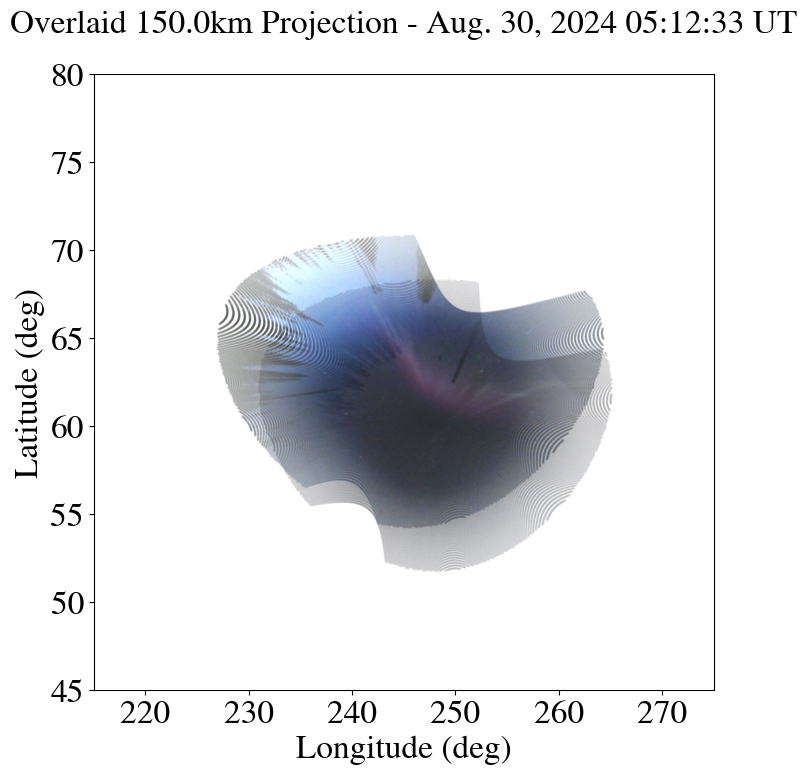

In [12]:
#h_target_arr = [100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000, 270000, 280000, 290000, 300000]
h_target_arr = [150000]
time_index = 251
site_name_yknf = "Yellowknife"
site_name_fsmi = "Fort Smith"


for h_target in h_target_arr:
    #----- YKNF ------ #
    lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
    lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
    full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
    full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]
    
    full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
    full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
    yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF
    
    
    yknf_lat_proj_arr, yknf_lon_proj_arr = spherical_project_lat_lon(full_azimuth_yknf, 
                                                                     full_elevation_yknf,
                                                                     lat_yknf,
                                                                     lon_yknf,
                                                                     h_target,
                                                                     yknf_110_mask
                                                                    )
    
    #----- FSMI ------ #
    lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
    lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
    full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
    full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]
    
    full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
    full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
    fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF

    
    fsmi_lat_proj_arr, fsmi_lon_proj_arr = spherical_project_lat_lon(full_azimuth_fsmi, 
                                                                             full_elevation_fsmi,
                                                                             lat_fsmi,
                                                                             lon_fsmi,
                                                                             h_target,
                                                                             yknf_110_mask
                                                                            )

    plot_lat_lon(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index, site_name_yknf, site_name_fsmi, 
                 yknf_lat_proj_arr, yknf_lon_proj_arr, fsmi_lat_proj_arr, fsmi_lon_proj_arr, h_target)
    


In [ ]:
lat: 60.5- 66
lon: 240 - 260